In [2]:
import pymcel as pc
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Bienvenido a PyMCel v0.9.17 ¡al infinito y más allá!


In [11]:
#Creamos la simulación
sim = rb.Simulation()

fecha_inicio = '2029-01-01'

sim.add('Sun', date=fecha_inicio)

# El código 399 forzará a Horizons a devolver las coordenadas puras del Geocentro (Tierra) 
# El código 301 forzará a Horizons a devolver las coordenadas puras de la Luna (evitando el baricentro)
sim.add('399', date=fecha_inicio, hash='Earth')  # Tierra
sim.add('301', date=fecha_inicio, hash='Moon')   # Luna
sim.add('JWST', date=fecha_inicio)  
sim.add('Jupiter', date=fecha_inicio)  
sim.add('Saturn', date=fecha_inicio)  
sim.add('Apophis', date=fecha_inicio, m = 3.06e-20)  # Asignamos masa a Apophis para que su gravedad sea real

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for 'JWST'... 
Found: James Webb Space Telescope (spacecraft) (-170) 
Searching NASA Horizons for 'Jupiter'... 


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for 'JWST'... 
Found: James Webb Space Telescope (spacecraft) (-170) 
Searching NASA Horizons for 'Jupiter'... 


c:\Users\ASUS\Downloads\Mecanica_cel\Mec-nica_Celeste-main\Mec-nica_Celeste\mecanicacelev\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for 'JWST'... 
Found: James Webb Space Telescope (spacecraft) (-170) 
Searching NASA Horizons for 'Jupiter'... 


c:\Users\ASUS\Downloads\Mecanica_cel\Mec-nica_Celeste-main\Mec-nica_Celeste\mecanicacelev\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


vamos a integrar la simulación, que comienza el primero de enero, durante 5 unidades de tiempo, que en términos de Rebound son aproximadamente 8 meses y medio, es decir, hasta mediados de agosto. Como el cometa pasa en abril, se cree que es un tiempo pertinente para observar todos los fenómenos deseados

In [4]:
N_pasos = 300 # Número de cuadros
t_max = 5 # 100 unidades de tiempo
ts = np.linspace(0, t_max, N_pasos) 

#Guardamos las posiciones y velocidades para los cuerpos
x_inis = [[] for _ in range(7)]
y_inis = [[] for _ in range(7)]
z_inis = [[] for _ in range(7)]
vx_inis = [[] for _ in range(7)]
vy_inis = [[] for _ in range(7)]
vz_inis = [[] for _ in range(7)]

#Integramos la simulación
for t in ts:
    sim.integrate(t)
    
    pos_tierra = sim.particles[1].xyz
    vel_tierra = sim.particles[1].vxyz

    for i, p in enumerate(sim.particles):
        # Guardamos posiciones relativas a la Tierra
        x_inis[i].append(p.x - pos_tierra[0])
        y_inis[i].append(p.y - pos_tierra[1])
        z_inis[i].append(p.z - pos_tierra[2])

        # De igual forma para las velocidades
        vx_inis[i].append(p.vx - vel_tierra[0])
        vy_inis[i].append(p.vy - vel_tierra[1])
        vz_inis[i].append(p.vz - vel_tierra[2])

In [12]:
# Nombres en el mismo orden exacto en el que los agregaste arriba a `sim`
nombres = ['Sol', 'Tierra', 'Luna', 'JWST', 'Júpiter', 'Saturno', 'Apophis']
colores_planetas = ['#FFD700', 'blue', 'gray', 'purple', '#FF4500', '#DEB887', '#FF0000']

# Para esta visualización centrada en la tierra usaremos un zoom manual
# En lugar de recalcularlo desde Apophis que podría estar super lejos (distorsionando la velocidad aparente)
limite = 0.05  # Limite fijo para enfocar bien Cislunar + JWST

paso_frame = max(1, N_pasos // 400) # Reducimos cantidad de frames para mejorar rendimiento

# ------------------- Configuración para los gráficos ------------------------------

layout_base = dict(
    width=860, height=760,
    margin=dict(l=0, r=0, b=0, t=50),
    scene=dict(
        xaxis=dict(title="X [AU]", range=[-limite, limite]),
        yaxis=dict(title="Y [AU]", range=[-limite, limite]),
        zaxis=dict(title="Z [AU]", range=[-limite, limite]),
        # Es vital fijar aspectmode a 'cube' para que las órbitas no se distorsionen ni se aplasten
        aspectmode='cube',
        camera=dict(
            eye=dict(x=0.1, y=0.1, z=0.1) # El zoom lo ampliamos para que la caja 3D sea visible
        )
    ),
    updatemenus=[dict(
        type='buttons',
        direction="left",
        pad={"r": 10, "t": 87},
        showactive=True,
        x=0.1,
        xanchor="right",
        y=0,
        yanchor="top",
        buttons=[
            dict(label='▶ Play',
                method='animate',
                args=[None, dict(frame=dict(duration=40, redraw=True), 
                                fromcurrent=True, mode='immediate', transition=dict(duration=0))]), 
            dict(label='⏸ Pausa',
                method='animate',
                args=[[None], dict(frame=dict(duration=0, redraw=True),
                                    mode='immediate', transition=dict(duration=0))])
        ]
    )],
    sliders=[dict(
        active=0,
        yanchor="top",
        xanchor="left",
        currentvalue=dict(
            font=dict(size=14),
            prefix="Frame: ",
            visible=True,
            xanchor="right"
        ),
        transition=dict(duration=0), 
        pad=dict(b=10, t=50),
        len=0.9,
        x=0.1,
        y=0,
        steps=[dict(method='animate',
                    args=[[str(fi)], dict(mode='immediate',
                                        frame=dict(duration=0, redraw=True), transition=dict(duration=0))], 
                    label=str(fi))
            for fi in range(0, N_pasos, paso_frame)] 
    )]
)

# Trazo inicial: primero las órbitas y luego la animación de los cuerpos
trazos_base = []

# Primero agregamos las órbitas completas estáticas para los 7 cuerpos
for i in range(7):
    # Ocultamos la trayectoria del Sol, Júpiter y Saturno por defecto para no ensuciar el acercamiento
    # Pueden encenderse dando clic en la leyenda, pero aquí enfocamos en Apophis
    visible_val = True if i in [1, 2, 3, 6] else 'legendonly'
    
    trazos_base.append(
        go.Scatter3d(
            x=x_inis[i], 
            y=y_inis[i], 
            z=z_inis[i],
            mode='lines',
            line=dict(color=colores_planetas[i], width=2),
            name=f'Órbita {nombres[i]}',
            visible=visible_val
        )
    )

# Luego agregamos la burbuja inicial estática (animable)
# IMPORTANTE: Plotly indexa cada trazo. Hemos agregado 7 trazos de líneas (órbitas).
# Por tanto, este trazo de los marcadores ocupará SÓLO el índice 7.
trazos_base.append(
    go.Scatter3d(
        x=[x_inis[i][0] for i in range(7)],
        y=[y_inis[i][0] for i in range(7)],
        z=[z_inis[i][0] for i in range(7)],
        mode='markers+text',
        text=nombres, textposition="top center",
        marker=dict(size=4, color=colores_planetas),
        showlegend=False
    )
)

# Animación del sistema solar SÓLO inyectando cambios al trazo de índice 7
fig1 = go.Figure(
    data=trazos_base,
    frames=[go.Frame(
        name=str(k),
        data=[
            go.Scatter3d(
                x=[x_inis[i][k] for i in range(7)],
                y=[y_inis[i][k] for i in range(7)],
                z=[z_inis[i][k] for i in range(7)]
            )
        ],
        traces=[7]
    ) for k in range(0, N_pasos, paso_frame)]
)

fig1.update_layout(**layout_base)
fig1.update_layout(title="Acercamiento: Tierra, Luna, JWST y Apophis")
fig1.show()

Para medir la perturbación exacta que ejerce Apophis sobre el JWST, creamos dos simulaciones y comparamos la desviación en la trayectoria. 

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for 'JWST'... 
Found: James Webb Space Telescope (spacecraft) (-170) 
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for 'JWST'... 
Found: James Webb Space Telescope (spacecraft) (-170) 
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 M

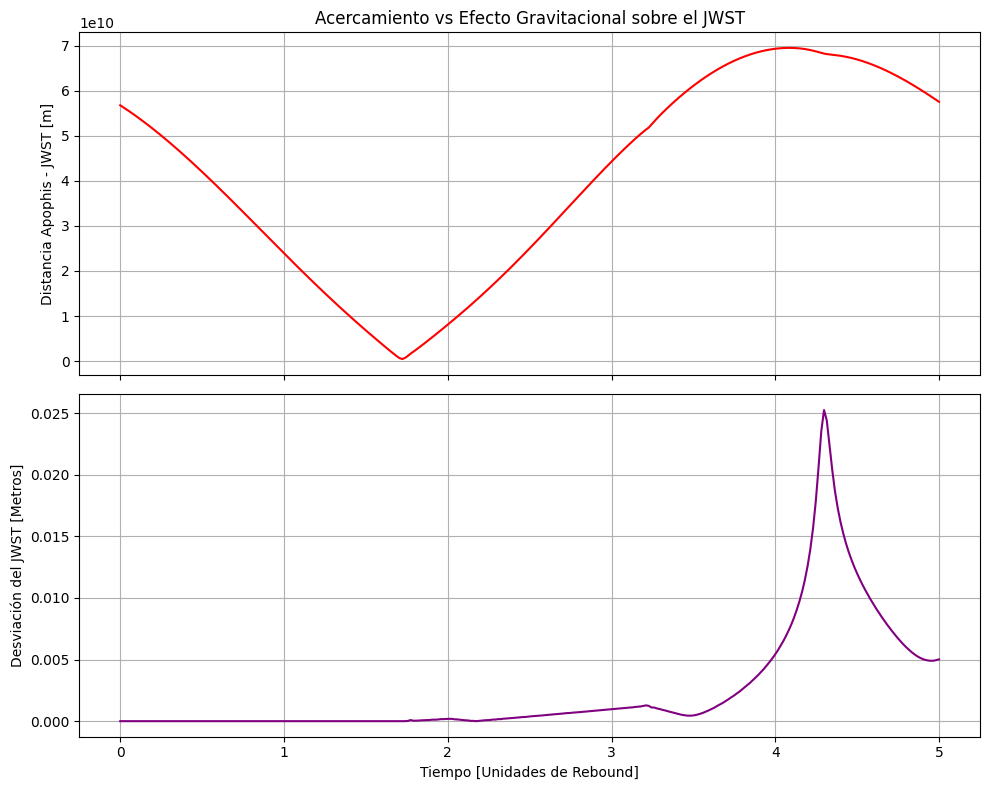

In [ ]:

# --- SIMULACIÓN SIN APOPHIS ---
sim_sin = rb.Simulation()
sim_sin.add('Sun', date=fecha_inicio)
sim_sin.add('399', date=fecha_inicio, hash='Earth')
sim_sin.add('301', date=fecha_inicio, hash='Moon')
sim_sin.add('JWST', date=fecha_inicio)
sim_sin.add('Jupiter', date=fecha_inicio)
sim_sin.add('Saturn', date=fecha_inicio)

# --- SIMULACIÓN CON APOPHIS ---
sim_con = rb.Simulation()
sim_con.add('Sun', date=fecha_inicio)
sim_con.add('399', date=fecha_inicio, hash='Earth')
sim_con.add('301', date=fecha_inicio, hash='Moon')
sim_con.add('JWST', date=fecha_inicio)
sim_con.add('Jupiter', date=fecha_inicio)
sim_con.add('Saturn', date=fecha_inicio)
sim_con.add('Apophis', date=fecha_inicio)


# Vectores para guardar la desviación del JWST a lo largo del tiempo
desviacion_JWST = []
distancia_Apo_JWST = []

# Integramos ambas y comparamos
for t in ts:
    sim_sin.integrate(t)
    sim_con.integrate(t)
    
    # Obtenemos la partícula 3 (JWST) en ambas simulaciones (0: Sol, 1: Tierra, 2: Luna, 3: JWST)
    pos_jwst_sin = np.array(sim_sin.particles[3].xyz)
    pos_jwst_con = np.array(sim_con.particles[3].xyz)
    
    # Calculamos la diferencia de posición (en Unidades Astronómicas)
    diferencia = np.linalg.norm(pos_jwst_con - pos_jwst_sin)
    desviacion_JWST.append(diferencia)
    
    # Adicionalmente calculamos la distancia entre Apophis (índice 6) y JWST
    pos_apo = np.array(sim_con.particles[6].xyz)
    distancia_Apo_JWST.append(np.linalg.norm(pos_apo - pos_jwst_con))

# Convertimos la desviación a un valor más legible, por ejemplo metros (1 AU ~ 1.496e11 metros)
desviacion_metros = np.array(desviacion_JWST) * 1.496e11
# Convertimos la distancia a metros (1 AU ~ 1.496e11 metros)
dist_m_array = np.array(distancia_Apo_JWST) * 1.496e11

# Gráfico del efecto
fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(ts, dist_m_array, color='red')
ax1.set_ylabel('Distancia Apophis - JWST [m]')
ax1.set_title('Acercamiento vs Efecto Gravitacional sobre el JWST')
ax1.grid()

ax2.plot(ts, desviacion_metros, color='purple')
ax2.set_ylabel('Desviación del JWST [Metros]')
ax2.set_xlabel('Tiempo [Unidades de Rebound]')
ax2.grid()

plt.tight_layout()
plt.show()

Como el cambio (desviación) máximo es de unos pocos metros –una distancia invisible a escala astronómica–, crearemos una animación centrada en el **James Webb**. Para poder visualizar el "mínimo cambio", dibujaremos al JWST original fijo en el centro, a Apophis pasando cerca, y a un "JWST Perturbado" cuya desviación multiplicaremos por un **factor de exageración** gigantesco ($10^8$) para que nuestros ojos puedan percibir cómo la gravedad de Apophis lo empuja.

In [17]:
# Variables para la animación "Microscópica"
escala_aumento = 1e20  # Factor para exagerar la desviación y poder verla
limite_jwst = 0.05    # Límite de visualización (Unidades Astronómicas alrededor del JWST)

# Vectores
x_jwst_fijo, y_jwst_fijo, z_jwst_fijo = [], [], []
x_jwst_desv, y_jwst_desv, z_jwst_desv = [], [], []
x_apo_rel, y_apo_rel, z_apo_rel = [], [], []

sim_sin = rb.Simulation()
sim_sin.add('Sun', date=fecha_inicio)
sim_sin.add('399', date=fecha_inicio, hash='Earth')
sim_sin.add('301', date=fecha_inicio, hash='Moon')
sim_sin.add('JWST', date=fecha_inicio)
sim_sin.add('Jupiter', date=fecha_inicio)
sim_sin.add('Saturn', date=fecha_inicio)

sim_con = rb.Simulation()
sim_con.add('Sun', date=fecha_inicio)
sim_con.add('399', date=fecha_inicio, hash='Earth')
sim_con.add('301', date=fecha_inicio, hash='Moon')
sim_con.add('JWST', date=fecha_inicio)
sim_con.add('Jupiter', date=fecha_inicio)
sim_con.add('Saturn', date=fecha_inicio)
sim_con.add('Apophis', date=fecha_inicio, m = 3.06e-10)

for t in ts:
    sim_sin.integrate(t)
    sim_con.integrate(t)
    
    p_jwst_sin = sim_sin.particles[3]
    p_jwst_con = sim_con.particles[3]
    p_apo_con = sim_con.particles[6]
    
    # El JWST original estará en el centro exacto (0,0,0)
    x_jwst_fijo.append(0)
    y_jwst_fijo.append(0)
    z_jwst_fijo.append(0)
    
    # El JWST perturbado es su diferencia multiplicada por la gran escala de aumento
    dx = (p_jwst_con.x - p_jwst_sin.x) * escala_aumento
    dy = (p_jwst_con.y - p_jwst_sin.y) * escala_aumento
    dz = (p_jwst_con.z - p_jwst_sin.z) * escala_aumento
    
    x_jwst_desv.append(dx)
    y_jwst_desv.append(dy)
    z_jwst_desv.append(dz)
    
    # La posición de Apophis será relativa al JWST "imperturbable" (el centro)
    # y la mostramos sin multiplicar! Es su distancia real respecto al telescopio.
    x_apo_rel.append(p_apo_con.x - p_jwst_sin.x)
    y_apo_rel.append(p_apo_con.y - p_jwst_sin.y)
    z_apo_rel.append(p_apo_con.z - p_jwst_sin.z)

# Configuración del gráfico centrado en JWST
layout_jwst = dict(
    width=800, height=700,
    scene=dict(
        xaxis=dict(title="X [AU]", range=[-limite_jwst, limite_jwst]),
        yaxis=dict(title="Y [AU]", range=[-limite_jwst, limite_jwst]),
        zaxis=dict(title="Z [AU]", range=[-limite_jwst, limite_jwst]),
        aspectmode='cube',
        camera=dict(
            eye=dict(x=0.1, y=0.1, z=0.1) # Zoom aplicado
        )
    ),
    updatemenus=[dict(type='buttons', direction="left", showactive=True, x=0.1, y=0,
        buttons=[
            dict(label='▶', method='animate', args=[None, dict(frame=dict(duration=20, redraw=True), mode='immediate')]),
            dict(label='⏸', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=True), mode='immediate')])
        ]
    )]
)

cuerpos_anim = ['JWST Normal', f'JWST Perturbado (Escala x{int(escala_aumento):.0E})', 'Apophis']
colores_anim = ['purple', 'cyan', 'red']

# Trazo inicial
trazo_jwst_anim = [
    go.Scatter3d(
        x=[x_jwst_fijo[0], x_jwst_desv[0], x_apo_rel[0]],
        y=[y_jwst_fijo[0], y_jwst_desv[0], y_apo_rel[0]],
        z=[z_jwst_fijo[0], z_jwst_desv[0], z_apo_rel[0]],
        mode='markers+text',
        text=cuerpos_anim, textposition="top center",
        marker=dict(size=[6, 5, 8], color=colores_anim)
    )
]

fig_jwst = go.Figure(
    data=trazo_jwst_anim,
    frames=[
        go.Frame(
            name=str(k),
            data=[go.Scatter3d(
                x=[x_jwst_fijo[k], x_jwst_desv[k], x_apo_rel[k]],
                y=[y_jwst_fijo[k], y_jwst_desv[k], y_apo_rel[k]],
                z=[z_jwst_fijo[k], z_jwst_desv[k], z_apo_rel[k]]
            )]
        ) for k in range(0, len(ts), paso_frame)
    ]
)

fig_jwst.update_layout(**layout_jwst)
fig_jwst.update_layout(title="Micro-Desviación del JWST (Cámara fija en el JWST original)")
fig_jwst.show()

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for 'JWST'... 
Found: James Webb Space Telescope (spacecraft) (-170) 
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '301'... 
Found: Moon (301) 
Searching NASA Horizons for 'JWST'... 
Found: James Webb Space Telescope (spacecraft) (-170) 
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 M